# Homework 1: Causality and Expressions

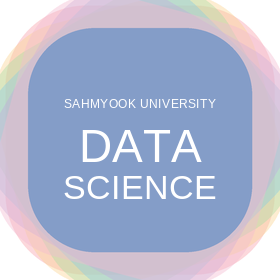

Please complete this notebook by filling in the cells provided. Before you begin, run the previous cell to load the provided tests.

**Recommended Readings:**

- [What is Data Science?](http://www.inferentialthinking.com/chapters/01/what-is-data-science.html)
- [Causality and Experiments](http://www.inferentialthinking.com/chapters/02/causality-and-experiments.html) 
- [Programming in Python](http://www.inferentialthinking.com/chapters/03/programming-in-python.html)

For all problems that you must write explanations and sentences for, you **must** provide your answer in the designated space. Moreover, throughout this homework and all future ones, please be sure to not re-assign variables throughout the notebook! For example, if you use `max_temperature` in your answer to one question, do not reassign it later on. Otherwise, you will fail tests that you thought you were passing previously!

Directly sharing answers is not okay, but discussing problems with the course staff or with other students is encouraged.

You should start early so that you have time to get help if you're stuck.

In [ ]:
# Setup (run this first!)
!pip install -q otter-grader datascience
!git clone https://github.com/jihyungkim94/datascience.git 2>/dev/null || true
import os, json
os.chdir('/content/datascience/hw/hw01')
os.makedirs('tests', exist_ok=True)
with open('hw01.ipynb') as _f:
    _nb = json.load(_f)
for _name, _test in _nb['metadata']['otter']['tests'].items():
    with open('tests/' + _name + '.py', 'w') as _f:
        _f.write('OK_FORMAT = True\n\ntest = ' + repr(_test) + '\n')
import otter
grader = otter.Notebook('hw01.ipynb')
print('Ready! (15 tests loaded)')

In [ ]:
# Just run this cell! 
# No need to worry about what this code means

from IPython.display import Javascript, display
display(Javascript(r"""
(() => {
  function pathLooksLikeTyping(e) {
    const path = e.composedPath ? e.composedPath() : [];
    for (const n of path) {
      if (!n) continue;
      if (n.tagName === 'INPUT' || n.tagName === 'TEXTAREA') return true;
      if (n.isContentEditable) return true;
      const role = n.getAttribute?.('role');
      if (role === 'textbox' || role === 'combobox' || role === 'searchbox') return true;
      const ariaMulti = n.getAttribute?.('aria-multiline');
      if (ariaMulti === 'true') return true;
      const cls = (n.className || "").toString().toLowerCase();
    }
    return false;
  }
  function handler(e) {
    if (e.key !== 'o' && e.key !== 'O') return;
    if (pathLooksLikeTyping(e)) {
      e.stopPropagation();
      if (e.stopImmediatePropagation) e.stopImmediatePropagation();
      if (e.nativeEvent?.stopImmediatePropagation) e.nativeEvent.stopImmediatePropagation();
      return;
    }
    e.preventDefault();
    e.stopPropagation();
    if (e.stopImmediatePropagation) e.stopImmediatePropagation();
    if (e.nativeEvent?.stopImmediatePropagation) e.nativeEvent.stopImmediatePropagation();
  }
  window.addEventListener('keydown', handler, true);
  window.addEventListener('keypress', handler, true);
  console.log("Installed: 'o' won't toggle output; 'o' should type inside any textbox-like UI (including JupyTutor).");
})();
"""))

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 1. Scary Arithmetic

---

**Question 1.1** An ad for ADT Security Systems says,

> "When you go on vacation, burglars go to work [...] According to FBI
statistics, over 25% of home burglaries occur between Memorial Day to Labor
Day."

Do the data in the ad support the claim that burglars are more likely to go to
work during the time between Memorial Day to Labor Day? Answer the
question by filling in the blanks below. For each blank, choose one of the
listed options. **(6 Points)**

`__(a)__`. Since `__(b)__`, we can conclude that `__(c)__`.

**Note:** You can assume that "over 25%" means only slightly over. Had it
been much over, say closer to 30%, then the marketers would have said so.

**Note:** Memorial Day is observed on the last Monday of May and Labor Day
is observed on the first Monday of September.

**Note:** If you run into a `NameError: name 'grader' is not defined` error in the autograder cell below (and in any assignment), please re-run the first cell at the very top of this notebook!

**Blank (a)** 
1. Yes 
2. No 
3. Not enough information

**Blank (b)** 

1. over 25% of home burglaries happen between Memorial Day and Labor Day, which is a large percentage
2. there is no controlled experiment in this observational analysis
3. the exact percentage of burglaries between Memorial Day and Labor Day is unknown
4. there is more than one plausible explanation for the high percentage of burglaries between Memorial Day and Labor Day
5. Labor Day is around 14 weeks after Memorial Day, which is slightly more than 25% of a year
6. the number of burglaries between Memorial Day and Labor Day varies from year to year

**Blank (c)** 

1. the number of burglaries is clearly elevated between Memorial Day and Labor Day
2. the rate of burglaries is clearly elevated between Memorial Day and Labor Day
3. the proportion of burglaries would be expected if burglars went to work at the same rate all year
4. the high rate of burgarlies in one year does not guarantee a high rate in future years
5. the evidence can neither support or deny this claim
6. the evidence is in favor of the claim

In [ ]:
a = ...
b = ...
c = ...

In [ ]:
grader.check("q1")

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 2. Characters in Little Women

In lecture, we counted the number of times that the literary characters were named in each chapter of the classic book, [*Little Women*](https://inferentialthinking.com/chapters/01/3/1/Literary_Characters.html?highlight=little%20women). In computer science, the word "character" also refers to a letter, digit, space, or punctuation mark; any single element of a text. The following code generates a scatter plot in which each dot corresponds to a chapter of *Little Women*. The horizontal position of a dot measures the number of periods in the chapter. The vertical position measures the total number of characters.

In [ ]:
# Just run this cell.

# This cell contains code that hasn't yet been covered in the course,
# but you should be able to interpret the scatter plot it generates.

from datascience import *
from urllib.request import urlopen
import numpy as np
%matplotlib inline

little_women_url = 'https://www.inferentialthinking.com/data/little_women.txt'
chapters = urlopen(little_women_url).read().decode().split('CHAPTER ')[1:]
text = Table().with_column('Chapters', chapters)
Table().with_columns(
    'Periods',    np.char.count(chapters, '.'),
    'Characters', text.apply(len, 0)
    ).scatter(0)

---

**Question 2.1.** Around how many periods are there in the chapter with the most characters? Assign either 1, 2, 3, 4, or 5 to the name `characters_q1` below. **(4 Points)**

1. 250
2. 390
3. 440
4. 32,000
5. 40,000

In [ ]:
characters_q1 = ...

In [ ]:
grader.check("q2_1")

---

**Question 2.2.** Which of the following chapters has the most characters *per* period? Assign either 1, 2, or 3 to the name `characters_q2` below. **(4 Points)**

1. The chapter with about 60 periods
2. The chapter with about 350 periods
3. The chapter with about 440 periods

In [ ]:
characters_q2 = ...

In [ ]:
grader.check("q2_2")

To discover more interesting facts from this plot, check out [Section 1.3.2](https://inferentialthinking.com/chapters/01/3/2/Another_Kind_Of_Character.html) in the textbook.

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 3. Names and Assignment Statements

---

**Question 3.1.** When you run the following cell, Python produces a cryptic error message.

In [ ]:
4 = 2 + 2

Choose the best explanation of what's wrong with the code, and then assign 1, 2, 3, or 4 to `names_q1` below to indicate your answer. **(4 Points)**

1. Python is smart and already knows `4 = 2 + 2`.

2. In Python, it's a rule that the `=` sign must have a variable name to its left, and `4` isn't a variable name.

3. It should be `2 + 2 = 4`.

4. I don't get an error message. This is a trick question.

In [ ]:
names_q1 = ...

In [ ]:
grader.check("q3_1")

---

**Question 3.2.** When you run the following cell, Python will produce another cryptic error message.

In [ ]:
two = 3
six = two plus two

Choose the best explanation of what's wrong with the code and assign 1, 2, 3, or 4 to `names_q2` below to indicate your answer. **(4 Points)**

1. The `plus` operation only applies to numbers, not the word "two".

2. The name "two" cannot be assigned to the number 3.

3. Two plus two is four, not six.

4. The name `plus` isn't a built-in operator; instead, addition uses `+`.

In [ ]:
names_q2 = ...

In [ ]:
grader.check("q3_2")

---

**Question 3.3.** Run the following cell.

In [ ]:
x = 2
y = 3 * x
x = 4

What is `y` after running this cell, and why? Choose the best explanation and assign 1, 2, 3, or 4 to `names_q3` below to indicate your answer. **(4 Points)**

1. `y` is equal to 6, because the second `x = 4` has no effect since `x` was already defined.

2. `y` is equal to 6, because `x` was 2 when `y` was assigned, and 3 * 2 is 6.

3. `y` is equal to 12, because `x` is 4 and 3 * 4 is 12.

4. `y` is equal to 12, because assigning `x` to 4 will update `y` to 12 since `y` was defined in terms of `x`.

In [ ]:
names_q3 = ...

In [ ]:
grader.check("q3_3")

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 4. Differences Between Majors

Berkeley’s Office of Planning and Analysis (OPA) provides data on numerous aspects of the campus. Adapted from the OPA website, the table below displays the number of degree recipients in three majors in the 2008-2009 and 2017-2018 academic years.

| Major                              | 2008-2009    | 2017-2018   |
|------------------------------------|--------------|-------------|
| Gender and Women's Studies         |      17      |    28       |
| Linguistics                        |      49      |    67       |
| Rhetoric                           |      113     |    56       |

---

**Question 4.1.** Suppose you want to find the **biggest** absolute difference between the number of degree recipients in the two years, among the three majors.

In the cell below, compute this value and call it `biggest_change`. Use a single expression (a single line of code) to compute the answer. Let Python perform all the arithmetic (like subtracting 49 from 67) rather than simplifying the expression yourself. The built-in `abs` function takes a numerical input and returns the absolute value. The built-in `max` function can take in 3 arguments and returns the maximum of the three numbers. **(5 Points)**

In [ ]:
biggest_change = ...
biggest_change

In [ ]:
grader.check("q4_1")

---

**Question 4.2.** Which of the three majors had the **smallest** absolute difference? Assign `smallest_change_major` to 1, 2, or 3 where each number corresponds to the following major:

1. Gender and Women's Studies  
2. Linguistics  
3. Rhetoric

Choose the number that corresponds to the major with the smallest absolute difference. **(4 Points)** 

_Hint:_ You should be able to answer by rough mental arithmetic, without having to calculate the exact value for each major.

In [ ]:
smallest_change_major = ...
smallest_change_major

In [ ]:
grader.check("q4_2")

---

**Question 4.3.**  For each major, define the “relative change” to be the following: $\large{\frac{\text{absolute difference}}{\text{value in 2008-2009}} * 100}$ 

Fill in the code below such that `gws_relative_change`, `linguistics_relative_change` and `rhetoric_relative_change` are assigned to the relative changes for their respective majors. **(5 Points)**

In [ ]:
gws_relative_change = (abs(...) / 17) * 100
linguistics_relative_change = ...
rhetoric_relative_change = ...
gws_relative_change, linguistics_relative_change, rhetoric_relative_change

In [ ]:
grader.check("q4_3")

---

**Question 4.4.** Assign `biggest_rel_change_major` to 1, 2, or 3 where each number corresponds to to the following: 

1. Gender and Women's Studies  
2. Linguistics  
3. Rhetoric

Choose the number that corresponds to the major with the biggest relative change. **(4 Points)**

In [ ]:
biggest_rel_change_major = ...
biggest_rel_change_major

In [ ]:
grader.check("q4_4")

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 5. Nearsightedness Study

[Myopia](https://en.wikipedia.org/wiki/Myopia), or nearsightedness, results from a number of genetic and environmental factors. In 1999, Quinn et al studied the relation between myopia and ambient lighting at night (for example, from nightlights or room lights) during childhood.

---

**Question 5.1.** The data were gathered by the following procedure, reported in
the study. "Between January and June 1998, parents of children aged 2-16 years
[...] that were seen as outpatients in a university pediatric ophthalmology clinic
completed a questionnaire on the child's light exposure both at present and before
the age of 2 years."

Was this study observational, or was it a controlled experiment? Assign either 1 or
2 to the name `study_type` below. **(5 Points)**

1. The study was observational because the researchers didn't perform any
intervention.

2. The study was a controlled experiment because the researchers decided which
treatments the participants received.

In [ ]:
study_type = ...

In [ ]:
grader.check("q5_1")

---

**Question 5.2.** The study found that of the children who slept with a room light on before the age of 2, 55% were myopic. Of the children who slept with a night light on before the age of 2, 34% were myopic. Of the children who slept in the dark before the age of 2, 10% were myopic. The study concluded the following: "The prevalence of myopia [...] during childhood was strongly associated with ambient light exposure during sleep at night in the first two years after birth."

Do the data support this statement? Assign either 1, 2, 3, or 4 to the name
`myopia_statement` below. **(5 Points)**

1. Yes, because sleeping with a room light on caused children in the study to
develop myopia.  
2. Yes, because there is a big difference in myopia rates between the groups.  
3. No, because only controlled experiments can show association.  
4. No, because there is no noticeable difference between the groups.  

In [ ]:
myopia_statement = ...

In [ ]:
grader.check("q5_2")

---

**Question 5.3.** On May 13, 1999, CNN reported the results of this study under the headline, "Night light may lead to nearsightedness." Does the original study claim that night light causes nearsightedness? Assign either 1 or 2 to the name `causation_answer` below. **(5 Points)**

1. Yes. We can infer causation from the study because the difference in groups is so large.
2. No. We cannot infer causation from the study because it was observational.
1. Yes. We can infer causation from the study because the fact that night lights may lead to nearsightedness is consistent with the data.
2. No. We cannot infer causation from the study because the difference in groups could be due to chance. 

In [ ]:
causation_answer = ...

In [ ]:
grader.check("q5_3")

---

**Question 5.4.** The final paragraph of the CNN report said that "several eye specialists" had pointed out that the study should have accounted for heredity.

Myopia is passed down from parents to children. Myopic parents are more likely to have myopic children, and may also be more likely to leave lights on habitually (since the parents have poor vision). In what ways does the knowledge of this possible genetic link affect how we interpret the data from the study?

Select all statements that are valid consequences of the possible genetic link between parents and children by assigning `myopia_factors` to a comma-separated sequence of numbers (e.g. `myopia_factors = 1, 3`). **(5 Points)**

1. If myopic parents are more likely to have myopic kids *and* leave the lights on at night, then myopic kids are more likely to have lights on at night.  
2. It is reasonable to assume that having myopic parents is a potential confounding factor that the original study did not account for.  
3. We are still able to find the observed association between night light exposure and myopia, even if night lights do not cause child myopia.  

In [ ]:
myopia_factors = ...

In [ ]:
grader.check("q5_4")

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 6. Studying the Survivors

---

**Question 6.1.** The Reverend Henry Whitehead was skeptical of John Snow’s conclusion about the Broad Street pump. After the Broad Street cholera epidemic ended, Whitehead set about trying to prove Snow wrong.  (The history of the event is detailed [in this historical account](http://www.ncbi.nlm.nih.gov/pmc/articles/PMC1034367/pdf/medhist00183-0026.pdf).)

He realized that Snow had focused his analysis almost entirely on those who had died. Whitehead, therefore, investigated the drinking habits of people in the Broad Street area who had not died in the outbreak.

What is the main reason it was important to study this group? Assign either 1, 2, or 3 to the name `survivor_answer` below. **(4 Points)**

1. If Whitehead had found that many people had drunk water from the Broad Street pump and not caught cholera, that would have been evidence against Snow's hypothesis.

2. Survivors could provide additional information about what else could have caused the cholera, potentially unearthing another cause.

3. Through considering the survivors, Whitehead could have identified a cure for cholera.

In [ ]:
survivor_answer = ...

In [ ]:
grader.check("q6_1")

**Note:** Whitehead ended up finding further proof that the Broad Street pump played a central role in spreading the disease to the people who lived near it. Eventually, he became one of Snow’s greatest defenders.

---

##  Submitting Your Work
All assignments in the course will be distributed as notebooks like this one, and you will submit your work from the notebook. We will use a system called Otter Grader to check your work and help you submit. If you haven’t already, make sure you have run the cell at the top of this notebook to initialize OtterGrader.



---

You're done with Homework 1! 

Please check that all test cases have passed for each question.*

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [ ]:
grader.check_all()

### Submission
1. Run `grader.check_all()` above and make sure all tests pass.
2. **File → Download → Download .ipynb**
3. Upload the `.ipynb` file to the LMS.

_(`grader.export()` does not work on Google Colab, so it has been removed.)_